# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [18]:
import torch

In [19]:
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

# Calculate - See pages 100 - 104
mean = x.mean(dim=-1, keepdim=True)
variance = x.var(dim=-1, keepdim=True, unbiased=False)
normalized_output = (x - mean) / torch.sqrt(variance + 1e-5)

print("Mean:", mean)
print("Variance:", variance)
print("Normalized output:", normalized_output)

Mean: tensor([[ 2.],
        [10.]])
Variance: tensor([[ 0.6667],
        [16.6667]])
Normalized output: tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  0.0000,  1.2247]])


In [20]:
# Verify with
normalized_output.mean(dim=-1)
normalized_output.var(dim=-1, unbiased=False)

tensor([1.0000, 1.0000])

## Section 3: Exploring GELU
Compare ReLU and GELU

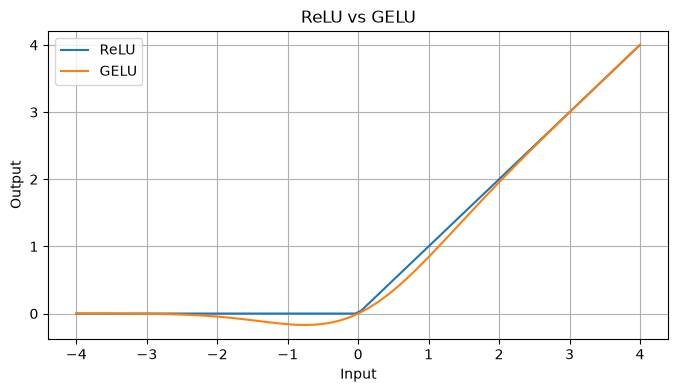

In [21]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use this and plot both
x = torch.linspace(-4, 4, 100)

relu_output = F.relu(x)
gelu_output = F.gelu(x)

plt.figure(figsize=(8, 4))
plt.plot(x, relu_output, label="ReLU")
plt.plot(x, gelu_output, label="GELU")
plt.title("ReLU vs GELU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [22]:
# Create
input_shape = (2, 3, 768)
x = torch.randn(input_shape)

In [23]:
# Pass through
# Linear - Expect (2,3,768)
linear1 = nn.Linear(768, 3072)
x1 = linear1(x)
print("After first Linear:", x1.shape)

# GELU - Expect (2,3,3072)
x2 = F.gelu(x1)
print("After GELU:", x2.shape)

# Linear again - Expect (2,3,768) again
linear2 = nn.Linear(3072, 768)
x3 = linear2(x2)
print("After second Linear:", x3.shape)

After first Linear: torch.Size([2, 3, 3072])
After GELU: torch.Size([2, 3, 3072])
After second Linear: torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [24]:
import torch.nn as nn

# Create a simple toy layer
layer = nn.Linear(768, 768)

# Sample input
x = torch.randn(2, 3, 768)

# Without residual connection
output_no_residual = layer(x)

# With residual connection
output_with_residual = x + layer(x)

print("Input shape:", x.shape)
print("Output shape without residual:", output_no_residual.shape)
print("Output shape with residual:", output_with_residual.shape)

Input shape: torch.Size([2, 3, 768])
Output shape without residual: torch.Size([2, 3, 768])
Output shape with residual: torch.Size([2, 3, 768])


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output